## Import & Data Load

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import json
from collections import defaultdict
from datetime import timedelta
from sklearn.ensemble import IsolationForest

# Load data
transactions = pd.read_csv(r"D:\Programs\flowguard\data\transactions.csv")
accounts = pd.read_csv(r"D:\Programs\flowguard\data\accounts.csv")

# Fix timestamp
transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])

print(f"Transactions : {len(transactions):,}")
print(f"Accounts     : {len(accounts):,}")
print(f"Fraud txns   : {transactions["is_fraud"].sum()} ({transactions["is_fraud"].mean()*100:.1f}%)")
print()
print(transactions.head())
print()
print(accounts.head())

Transactions : 3,316
Accounts     : 200
Fraud txns   : 316 (9.5%)

      txn_id  sender_id receiver_id  amount           timestamp  is_fraud  \
0  TXN481219  ACC182627   ACC725380   28225 2024-01-01 01:29:00         0   
1  TXN207629  ACC813536   ACC864544    2848 2024-01-01 02:57:00         0   
2  TXN477496  ACC835392   ACC379786   26523 2024-01-01 03:25:00         0   
3  TXN590737  ACC759176   ACC452944   20160 2024-01-01 06:10:00         0   
4  TXN997728  ACC883300   ACC169403    9308 2024-01-01 12:36:00         0   

  fraud_pattern  
0          none  
1          none  
2          none  
3          none  
4          none  

  account_id account_type creation_date   status risk_profile
0  ACC198246      savings    2023-09-20   active         high
1  ACC850800     business    2020-02-12   active         high
2  ACC460663      savings    2022-01-09  dormant          low
3  ACC542666     business    2019-01-02   active       medium
4  ACC671858      savings    2019-02-09   active   

## Build Graph

In [2]:
G = nx.DiGraph()
# Attach account metadata first
for _, row in accounts.iterrows():
    G.add_node(row["account_id"],
               account_type = row["account_type"],
               status = row["status"],
               risk_profile = row["risk_profile"],
               creation_date = row["creation_date"])

# If multiple transactions exist between same A→B, keep the highest-amount one
# Full history is always queried from the DataFrame when needed
for _, row in transactions.iterrows():
    s, r = row["sender_id"], row["receiver_id"]
    if G.has_edge(s, r):
        if row["amount"] > G[s][r]["amount"]:
            G[s][r].update(
                txn_id = row["txn_id"],
                amount = row["amount"],
                timestamp = row["timestamp"],
                is_fraud = row["is_fraud"],
                fraud_pattern = row["fraud_pattern"]
            )
    else:
        G.add_edge(s, r,
                   txn_id = row["txn_id"],
                   amount = row["amount"],
                   timestamp = row["timestamp"],
                   is_fraud = row["is_fraud"],
                   fraud_pattern = row["fraud_pattern"])
print(f"Nodes : {G.number_of_nodes()}")
print(f"Edges : {G.number_of_edges()}")
print(f"Density : {nx.density(G):.5f}")

Nodes : 200
Edges : 3062
Density : 0.07693


In [3]:
print("Sample nodes:")
for node in list(G.nodes(data=True))[:3]:
    print(" ", node)

print("\nSample edges:")
for edge in list(G.edges(data=True))[:3]:
    print(" ", edge)

Sample nodes:
  ('ACC198246', {'account_type': 'savings', 'status': 'active', 'risk_profile': 'high', 'creation_date': '2023-09-20'})
  ('ACC850800', {'account_type': 'business', 'status': 'active', 'risk_profile': 'high', 'creation_date': '2020-02-12'})
  ('ACC460663', {'account_type': 'savings', 'status': 'dormant', 'risk_profile': 'low', 'creation_date': '2022-01-09'})

Sample edges:
  ('ACC198246', 'ACC684004', {'txn_id': 'TXN864234', 'amount': 37690, 'timestamp': Timestamp('2024-01-24 13:55:00'), 'is_fraud': 0, 'fraud_pattern': 'none'})
  ('ACC198246', 'ACC671858', {'txn_id': 'TXN345896', 'amount': 44516, 'timestamp': Timestamp('2024-03-05 19:26:00'), 'is_fraud': 0, 'fraud_pattern': 'none'})
  ('ACC198246', 'ACC380746', {'txn_id': 'TXN926952', 'amount': 9982, 'timestamp': Timestamp('2024-04-04 15:46:00'), 'is_fraud': 0, 'fraud_pattern': 'none'})


In [4]:
print("Total Nodes:", G.number_of_nodes())
print("Total Accounts:", len(accounts))

Total Nodes: 200
Total Accounts: 200


## Community Detection -> Louvain Algorithm

In [5]:
import community as community_louvain
# Louvain works on undirected graphs
G_undirected = G.to_undirected()
partition = community_louvain.best_partition(G_undirected)
# Attach community ID to each node
for node, community_id in partition.items():
    G.nodes[node]["community"] = community_id
# Group accounts by community
community_groups = defaultdict(list)
for node, cid in partition.items():
    community_groups[cid].append(node)
# Find large communities (likely fraud rings)
large_communities = {cid: members for cid, members in community_groups.items()
                     if len(members) >= 4}
print(f"Total communities detected : {len(community_groups)}")
print(f"Large communities (≥4 accs): {len(large_communities)}")
print()
for cid, members in sorted(large_communities.items(),
                            key=lambda x: len(x[1]), reverse=True)[:5]:
    print(f"  Community {cid} → {len(members)} accounts: {members[:5]}{'...' if len(members)>5 else ""}")

Total communities detected : 56
Large communities (≥4 accs): 6

  Community 11 → 31 accounts: ['ACC671858', 'ACC802729', 'ACC814825', 'ACC148050', 'ACC133326']...
  Community 0 → 28 accounts: ['ACC198246', 'ACC555884', 'ACC542417', 'ACC379946', 'ACC131244']...
  Community 5 → 28 accounts: ['ACC779514', 'ACC738720', 'ACC145561', 'ACC329974', 'ACC748564']...
  Community 3 → 24 accounts: ['ACC542666', 'ACC344098', 'ACC375504', 'ACC590785', 'ACC207473']...
  Community 10 → 20 accounts: ['ACC158655', 'ACC271339', 'ACC518801', 'ACC197251', 'ACC865179']...


## Basic Graph Plot

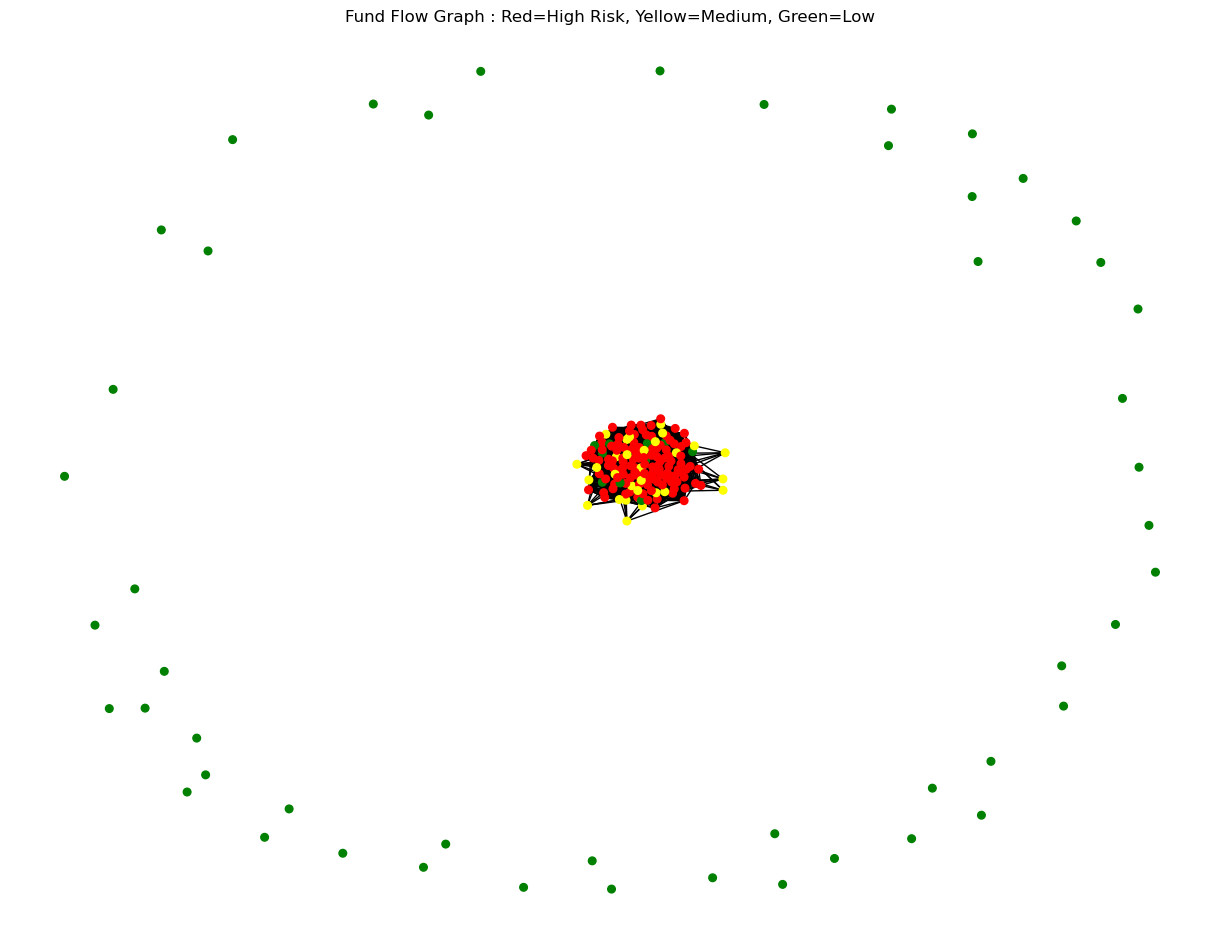

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))
pos = nx.spring_layout(G, k=0.15, seed=42)
# Color nodes by risk profile
color_map = {"high": "red", "medium": "yellow", "low": "green"}
node_colors = [color_map.get(G.nodes[n].get("risk_profile", "low"), "green") for n in G.nodes()]

nx.draw(G, pos, node_size=30, node_color=node_colors, with_labels=False, arrows=False)
plt.title("Fund Flow Graph : Red=High Risk, Yellow=Medium, Green=Low")
plt.show()

## Cycle Detection

In [7]:
scored_cycles = []
for u in G.nodes():
    for v in G.successors(u):
        for w in G.successors(v):
            if w == u:
                continue
            if G.has_edge(w, u):
                t1 = G[u][v]["timestamp"]
                t2 = G[v][w]["timestamp"]
                t3 = G[w][u]["timestamp"]
                a1 = G[u][v]["amount"]
                a2 = G[v][w]["amount"]
                a3 = G[w][u]["amount"]

                time_diff   = (t3 - t1).total_seconds()
                amount_diff = max(a1, a2, a3) - min(a1, a2, a3)

                score = 0
                if time_diff < 3600:    score += 2  # within 1 hour
                if amount_diff < 10000: score += 2  # similar amounts
                if min(a1,a2,a3) > 10000: score += 1  # high value

                if score >= 3:
                    scored_cycles.append({
                        "cycle": [u, v, w],
                        "score": score,
                        "time_diff": time_diff,
                        "amount_diff": amount_diff
                    })
top_cycles = sorted(scored_cycles, key=lambda x: x["score"], reverse=True)[:10]
print(f"Circular patterns found: {len(top_cycles)}")
for c in top_cycles:
    print(f"  {" → ".join(c["cycle"])} → {c["cycle"][0]}   score={c["score"]}")

Circular patterns found: 10
  ACC198246 → ACC488162 → ACC322955 → ACC198246   score=5
  ACC198246 → ACC321231 → ACC331148 → ACC198246   score=5
  ACC198246 → ACC319684 → ACC403445 → ACC198246   score=5
  ACC850800 → ACC172933 → ACC148050 → ACC850800   score=5
  ACC850800 → ACC195325 → ACC865179 → ACC850800   score=5
  ACC850800 → ACC654816 → ACC379946 → ACC850800   score=5
  ACC850800 → ACC403445 → ACC857168 → ACC850800   score=5
  ACC850800 → ACC900581 → ACC131244 → ACC850800   score=5
  ACC542666 → ACC910620 → ACC705397 → ACC542666   score=5
  ACC542666 → ACC898975 → ACC654816 → ACC542666   score=5


## Layering Detection

In [8]:
scored_layering = []
for u in G.nodes():
    for v in G.successors(u):
        for w in G.successors(v):
            for x in G.successors(w):
                if len({u, v, w, x}) < 4:
                    continue

                t1 = G[u][v]["timestamp"]
                t2 = G[v][w]["timestamp"]
                t3 = G[w][x]["timestamp"]
                a1 = G[u][v]["amount"]
                a2 = G[v][w]["amount"]
                a3 = G[w][x]["amount"]

                score = 0
                if (t2 - t1) <= timedelta(minutes=15): score += 1
                if (t3 - t2) <= timedelta(minutes=15): score += 1
                if max(a1,a2,a3) - min(a1,a2,a3) < 10000: score += 1

                if score >= 2:
                    scored_layering.append({
                        "path": [u, v, w, x],
                        "score": score
                    })

top_layering = sorted(scored_layering, key=lambda x: x["score"], reverse=True)[:10]
print(f"Layering patterns found: {len(top_layering)}")
for l in top_layering:
    print(f"  {" → ".join(l["path"])}   score={l["score"]}")

Layering patterns found: 10
  ACC198246 → ACC380746 → ACC883300 → ACC169403   score=3
  ACC198246 → ACC380746 → ACC377746 → ACC133326   score=3
  ACC198246 → ACC380746 → ACC377746 → ACC944151   score=3
  ACC198246 → ACC380746 → ACC832052 → ACC974628   score=3
  ACC198246 → ACC380746 → ACC356702 → ACC555884   score=3
  ACC198246 → ACC379946 → ACC358607 → ACC131244   score=3
  ACC198246 → ACC379946 → ACC765822 → ACC452944   score=3
  ACC198246 → ACC379946 → ACC383060 → ACC344098   score=3
  ACC198246 → ACC379946 → ACC383060 → ACC802729   score=3
  ACC198246 → ACC488162 → ACC358607 → ACC898975   score=3


## Mule Detection

In [9]:
mule_accounts = []
for node in G.nodes():
    in_degree  = G.in_degree(node)
    out_degree = G.out_degree(node)
    total      = in_degree + out_degree
    if total < 8:
        continue

    imbalance = float("inf") if min(in_degree, out_degree) == 0 \
                else max(in_degree, out_degree) / min(in_degree, out_degree)

    if imbalance >= 2.5:
        mule_accounts.append({
            "account":    node,
            "in_degree":  in_degree,
            "out_degree": out_degree,
            "imbalance":  round(imbalance, 2)
        })

print(f"Mule accounts found: {len(mule_accounts)}")
for m in sorted(mule_accounts, key=lambda x: x["imbalance"], reverse=True):
    print(f"  {m["account"]}  in={m["in_degree"]} out={m["out_degree"]} imbalance={m["imbalance"]}x")

Mule accounts found: 7
  ACC779514  in=0 out=8 imbalance=infx
  ACC688508  in=0 out=9 imbalance=infx
  ACC766563  in=0 out=10 imbalance=infx
  ACC813328  in=0 out=8 imbalance=infx
  ACC301629  in=0 out=8 imbalance=infx
  ACC733052  in=0 out=9 imbalance=infx
  ACC430776  in=28 out=10 imbalance=2.8x


## Structuring Detection

In [10]:
structuring_cases = []
for sender in set(transactions["sender_id"]):
    txns_list = (transactions[transactions["sender_id"] == sender]
                 .sort_values("timestamp")
                 .to_dict("records"))
    used = set()

    for i in range(len(txns_list)):
        if i in used:
            continue
            
        if not (45000 <= txns_list[i]["amount"] <= 50000):
            continue

        cluster = [txns_list[i]]
        indices = [i]

        for j in range(i + 1, len(txns_list)):
            delta = txns_list[j]["timestamp"] - txns_list[i]["timestamp"]
            if delta <= timedelta(hours=24) and 45000 <= txns_list[j]["amount"] <= 50000:
                cluster.append(txns_list[j])
                indices.append(j)
            elif delta > timedelta(hours=24):
                break

        if len(cluster) >= 3:
            structuring_cases.append({
                "sender":       sender,
                "count":        len(cluster),
                "transactions": cluster
            })
            used.update(indices)
print(f"Structuring cases found: {len(structuring_cases)}")
for s in structuring_cases:
    print(f"  {s["sender"]} → {s["count"]} transactions in ₹45k–₹50k range")

Structuring cases found: 10
  ACC452944 → 6 transactions in ₹45k–₹50k range
  ACC498591 → 5 transactions in ₹45k–₹50k range
  ACC930555 → 4 transactions in ₹45k–₹50k range
  ACC624902 → 5 transactions in ₹45k–₹50k range
  ACC330283 → 3 transactions in ₹45k–₹50k range
  ACC479580 → 4 transactions in ₹45k–₹50k range
  ACC271339 → 6 transactions in ₹45k–₹50k range
  ACC663054 → 3 transactions in ₹45k–₹50k range
  ACC814825 → 3 transactions in ₹45k–₹50k range
  ACC172933 → 6 transactions in ₹45k–₹50k range


## Dormant Activation

In [11]:
dormant_activations = []
for node in G.nodes():
    if G.nodes[node].get("status") != "dormant":
        continue

    outgoing = list(G.out_edges(node, data=True))
    incoming = list(G.in_edges(node, data=True))
    total_txns   = len(outgoing) + len(incoming)

    if total_txns == 0:
        continue
    total_amount = (sum(d[2]["amount"] for d in outgoing) +
                    sum(d[2]["amount"] for d in incoming))

    if total_txns >= 3 or total_amount > 50000:
        dormant_activations.append({
            "account":      node,
            "transactions": total_txns,
            "total_amount": total_amount
        })
dormant_activations = sorted(dormant_activations, key=lambda x: x["total_amount"], reverse=True)
print(f"Dormant activations found: {len(dormant_activations)}")
for d in dormant_activations[:5]:
    print(f"  {d["account"]}  txns={d["transactions"]}  total=₹{d["total_amount"]:,.0f}")

Dormant activations found: 8
  ACC766563  txns=10  total=₹318,685
  ACC688508  txns=9  total=₹291,934
  ACC733052  txns=9  total=₹271,590
  ACC301629  txns=8  total=₹255,941
  ACC813328  txns=8  total=₹253,942


## Flow Conservation

In [12]:
flow_conservation_cases = []
for cid, members in large_communities.items():
    member_set = set(members)
    inflow = sum(
        data["amount"]
        for u, v, data in G.edges(data=True)
        if v in member_set and u not in member_set
    )
    # Money going OUT of this community to outside
    outflow = sum(
        data["amount"]
        for u, v, data in G.edges(data=True)
        if u in member_set and v not in member_set
    )
    if inflow == 0 or outflow == 0:
        continue

    # Conservation ratio — real laundering keeps this close to 1.0
    ratio = min(inflow, outflow) / max(inflow, outflow)

    if ratio >= 0.75:  
        flow_conservation_cases.append({
            "community_id": cid,
            "members":      members,
            "inflow":       inflow,
            "outflow":      outflow,
            "ratio":        round(ratio, 3)
        })

flow_conservation_cases = sorted(flow_conservation_cases,
                                  key=lambda x: x["ratio"], reverse=True)
print(f"Flow-conserved communities: {len(flow_conservation_cases)}")
for fc in flow_conservation_cases:
    print(f"  Community {fc["community_id"]} → "
          f"in=₹{fc["inflow"]:,.0f} out=₹{fc["outflow"]:,.0f} "
          f"ratio={fc["ratio"]} [{len(fc["members"])} accounts]")

Flow-conserved communities: 6
  Community 11 → in=₹10,566,621 out=₹10,719,535 ratio=0.986 [31 accounts]
  Community 5 → in=₹9,583,719 out=₹9,893,992 ratio=0.969 [28 accounts]
  Community 10 → in=₹7,669,777 out=₹8,052,005 ratio=0.953 [20 accounts]
  Community 0 → in=₹9,887,946 out=₹9,126,271 ratio=0.923 [28 accounts]
  Community 3 → in=₹8,630,116 out=₹7,906,230 ratio=0.916 [24 accounts]
  Community 1 → in=₹6,698,363 out=₹7,338,509 ratio=0.913 [19 accounts]


## Risk Scoring - Rule-Based

In [17]:
risk_scores = defaultdict(int)
# Pattern scores
for c in top_cycles:
    for acc in c["cycle"]:
        risk_scores[acc] += 5      # highest — money literally returns to origin

for l in top_layering:
    for acc in l["path"]:
        risk_scores[acc] += 3

for m in mule_accounts:
    risk_scores[m["account"]] += 3

for s in structuring_cases:
    risk_scores[s["sender"]] += 2

for d in dormant_activations:
    risk_scores[d["account"]] += 2

# Community amplification
for c in top_cycles:
    communities_in_cycle = set(partition.get(acc, -1) for acc in c["cycle"])
    if len(communities_in_cycle) == 1:  # all same community = coordinated ring
        for acc in c["cycle"]:
            risk_scores[acc] += 3

for l in top_layering:
    communities_in_path = set(partition.get(acc, -1) for acc in l["path"])
    if len(communities_in_path) == 1:
        for acc in l["path"]:
            risk_scores[acc] += 2

# Flow conservation boost
for fc in flow_conservation_cases:
    for acc in fc["members"]:
        risk_scores[acc] += 3

# Temporal velocity boost 
for node in G.nodes():
    txns_out = transactions[transactions["sender_id"]   == node]
    txns_in  = transactions[transactions["receiver_id"] == node]
    all_txns = pd.concat([txns_out, txns_in]).sort_values("timestamp")
    recent_cutoff = transactions["timestamp"].max() - pd.Timedelta(days=30)
    recent   = all_txns[all_txns["timestamp"] >= recent_cutoff]["amount"].mean() or 0
    historic = all_txns[all_txns["timestamp"] <  recent_cutoff]["amount"].mean() or 1
    if (recent / max(historic, 1)) >= 3.0:
        risk_scores[node] += 2
        
print("Top 10 accounts by rule score:")
for acc, score in sorted(risk_scores.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {acc}  →  {score}")

Top 10 accounts by rule score:
  ACC198246  →  58
  ACC850800  →  28
  ACC379946  →  22
  ACC380746  →  20
  ACC488162  →  14
  ACC403445  →  13
  ACC654816  →  13
  ACC131244  →  13
  ACC542666  →  13
  ACC322955  →  11


## PageRank

In [18]:
# PageRank on transaction graph
# High PageRank = money flows through this account heavily -> higher suspicion if also in fraud pattern
pagerank = nx.pagerank(G, alpha=0.85, max_iter=200)
# Boost risk score for high-influence accounts
for node in G.nodes():
    if pagerank.get(node, 0) > 0.01:
        risk_scores[node] += 2
print("\nTop 10 accounts by PageRank:")
for acc, pr in sorted(pagerank.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {acc}  PageRank={pr:.5f}  RuleScore={risk_scores.get(acc, 0)}")


Top 10 accounts by PageRank:
  ACC900581  PageRank=0.01014  RuleScore=10
  ACC802729  PageRank=0.00940  RuleScore=6
  ACC854639  PageRank=0.00934  RuleScore=3
  ACC671412  PageRank=0.00932  RuleScore=3
  ACC158655  PageRank=0.00930  RuleScore=3
  ACC356702  PageRank=0.00908  RuleScore=8
  ACC571029  PageRank=0.00899  RuleScore=3
  ACC263032  PageRank=0.00889  RuleScore=3
  ACC430776  PageRank=0.00882  RuleScore=6
  ACC898975  PageRank=0.00865  RuleScore=11


## Behavioral Features & Isolation Forest

In [19]:
features = []
for node in G.nodes():
    txns_out = transactions[transactions["sender_id"]   == node]
    txns_in  = transactions[transactions["receiver_id"] == node]
    all_txns = pd.concat([txns_out, txns_in]).sort_values("timestamp")
    n = len(all_txns)

    if n == 0:
        features.append({
            "account": node, "in_degree": 0, "out_degree": 0,
            "total_degree": 0, "num_transactions": 0, "avg_amount": 0,
            "std_amount": 0, "unique_counterparties": 0,
            "night_txn_ratio": 0, "txns_per_hour": 0,
            "centrality": 0, "pagerank": pagerank.get(node, 0),
            "velocity_ratio": 0, "recent_spike": 0
        })
        continue

    # Temporal velocity — inside the loop, per account
    recent_cutoff = transactions["timestamp"].max() - pd.Timedelta(days=30)
    recent_txns   = all_txns[all_txns["timestamp"] >= recent_cutoff]
    historic_txns = all_txns[all_txns["timestamp"] <  recent_cutoff]
    recent_avg    = recent_txns["amount"].mean()   if len(recent_txns)   > 0 else 0
    historic_avg  = historic_txns["amount"].mean() if len(historic_txns) > 0 else 1
    velocity_ratio = round(recent_avg / max(historic_avg, 1), 3)
    recent_spike   = 1 if velocity_ratio >= 3.0 else 0

    counterparties = set(txns_out["receiver_id"]).union(set(txns_in["sender_id"]))
    hours          = pd.to_datetime(all_txns["timestamp"]).dt.hour
    night_ratio    = float(((hours >= 22) | (hours <= 6)).sum()) / n
    time_span_hrs  = max(1, (all_txns["timestamp"].max() - all_txns["timestamp"].min()).total_seconds() / 3600)

    features.append({
        "account":               node,
        "in_degree":             G.in_degree(node),
        "out_degree":            G.out_degree(node),
        "total_degree":          G.in_degree(node) + G.out_degree(node),
        "num_transactions":      n,
        "avg_amount":            all_txns["amount"].mean(),
        "std_amount":            all_txns["amount"].std() if n > 1 else 0,
        "unique_counterparties": len(counterparties),
        "night_txn_ratio":       round(night_ratio, 4),
        "txns_per_hour":         round(n / time_span_hrs, 4),
        "centrality":            nx.betweenness_centrality(G).get(node, 0),
        "pagerank":              pagerank.get(node, 0),
        "velocity_ratio":        velocity_ratio,
        "recent_spike":          recent_spike
    })

features_df = pd.DataFrame(features)
X = features_df.drop(columns=["account"]).fillna(0)
model = IsolationForest(contamination=0.1, random_state=42)
features_df["anomaly"] = (model.fit_predict(X) == -1).astype(int)
ml_risk_scores = dict(zip(features_df["account"], features_df["anomaly"]))

print(f"ML anomalies flagged: {features_df['anomaly'].sum()}")
print()
print(features_df[features_df["anomaly"] == 1][
    ["account","num_transactions","avg_amount","unique_counterparties","night_txn_ratio","velocity_ratio"]
].head(8).to_string(index=False))

ML anomalies flagged: 20

  account  num_transactions   avg_amount  unique_counterparties  night_txn_ratio  velocity_ratio
ACC198246                32 18417.437500                     28           0.3438           1.022
ACC779514                 8 29184.875000                      8           0.3750           0.000
ACC158655                61 26505.245902                     50           0.4590           0.436
ACC688508                 9 32437.111111                      9           0.5556           0.000
ACC581141                 6 29681.000000                      6           0.6667           0.000
ACC671412                50 20130.540000                     41           0.2800           0.896
ACC766563                10 31868.500000                     10           0.6000           0.000
ACC575763                33 23880.151515                     30           0.4848           1.884


## Final Risk Score

In [20]:
final_risk_scores = {}
for acc in G.nodes():
    rule_score = risk_scores.get(acc, 0)
    ml_flag    = ml_risk_scores.get(acc, 0)
    final_risk_scores[acc] = rule_score + (3 if ml_flag else 0)

def risk_label(score):
    if score >= 10: return "HIGH"
    if score >= 4:  return "MEDIUM"
    return "LOW"
print("Top 15 accounts by final risk score:")
for acc, score in sorted(final_risk_scores.items(), key=lambda x: x[1], reverse=True)[:15]:
    ml  = " -> ML" if ml_risk_scores.get(acc) else ""
    print(f"  {acc}  score={score:3d}  [{risk_label(score)}]{ml}")

Top 15 accounts by final risk score:
  ACC198246  score= 61  [HIGH] -> ML
  ACC850800  score= 28  [HIGH]
  ACC379946  score= 22  [HIGH]
  ACC380746  score= 20  [HIGH]
  ACC488162  score= 14  [HIGH]
  ACC358607  score= 14  [HIGH] -> ML
  ACC542666  score= 13  [HIGH]
  ACC131244  score= 13  [HIGH]
  ACC403445  score= 13  [HIGH]
  ACC900581  score= 13  [HIGH] -> ML
  ACC654816  score= 13  [HIGH]
  ACC779514  score= 11  [HIGH] -> ML
  ACC322955  score= 11  [HIGH]
  ACC688508  score= 11  [HIGH] -> ML
  ACC766563  score= 11  [HIGH] -> ML


## Plotly Graph

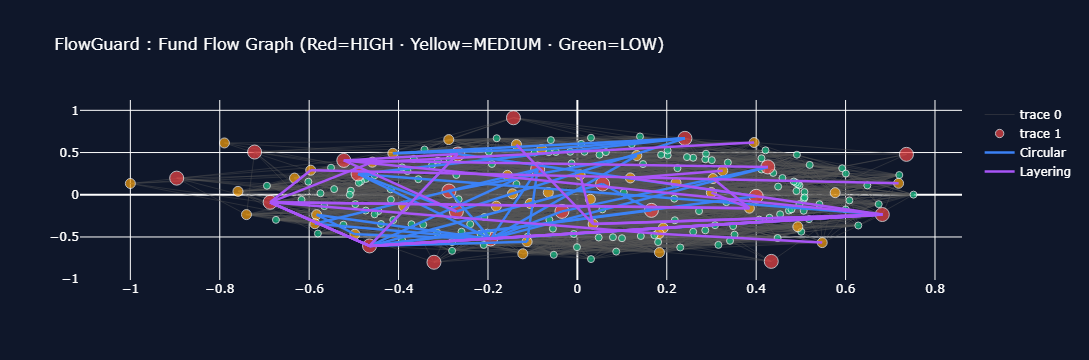

In [21]:
import plotly.graph_objects as go
pos = nx.kamada_kawai_layout(G)
# Base edges (high-value only to reduce clutter)
edge_x, edge_y = [], []
for u, v, data in G.edges(data=True):
    if data["amount"] < 20000: continue
    x0, y0 = pos[u]; x1, y1 = pos[v]
    edge_x += [x0, x1, None]; edge_y += [y0, y1, None]

edge_trace = go.Scatter(x=edge_x, y=edge_y, mode='lines',
                        line=dict(width=0.4, color='#555'), hoverinfo='none')

# Nodes colored by final risk
node_x, node_y, node_color, node_text, node_size = [], [], [], [], []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x); node_y.append(y)
    score = final_risk_scores.get(node, 0)
    color = "#ef4444" if score >= 10 else "#f59e0b" if score >= 4 else "#10b981"
    size  = 14 if score >= 10 else 10 if score >= 4 else 7
    node_color.append(color); node_size.append(size)
    ml = " | ML Anomaly" if ml_risk_scores.get(node) else ""
    node_text.append(f"<b>{node}</b><br>Score: {score} [{risk_label(score)}]<br>Community: {partition.get(node, '?')}{' | ML' if ml_risk_scores.get(node) else ''}")

node_trace = go.Scatter(x=node_x, y=node_y, mode="markers", text=node_text,
                        hoverinfo="text",
                        marker=dict(size=node_size, color=node_color,
                                    line=dict(width=1, color="white")))

# Cycle edges (blue)
cx, cy = [], []
for c in top_cycles:
    cyc = c["cycle"]
    for i in range(len(cyc)):
        u, v = cyc[i], cyc[(i+1) % len(cyc)]
        if G.has_edge(u, v):
            x0,y0=pos[u]; x1,y1=pos[v]
            cx += [x0,x1,None]; cy += [y0,y1,None]
cycle_trace = go.Scatter(x=cx, y=cy, mode="lines",
                         line=dict(width=2.5, color="#3b82f6"), name="Circular")

# Layering edges (purple)
lx, ly = [], []
for l in top_layering:
    for i in range(len(l["path"]) - 1):
        u, v = l["path"][i], l["path"][i+1]
        if G.has_edge(u, v):
            x0,y0=pos[u]; x1,y1=pos[v]
            lx += [x0,x1,None]; ly += [y0,y1,None]
layer_trace = go.Scatter(x=lx, y=ly, mode="lines",
                         line=dict(width=2.5, color="#a855f7"), name="Layering")

fig = go.Figure(
    data=[edge_trace, node_trace, cycle_trace, layer_trace],
    layout=go.Layout(
        title=dict(text="FlowGuard : Fund Flow Graph (Red=HIGH · Yellow=MEDIUM · Green=LOW)",
                   font=dict(size=16)),
        hovermode="closest", showlegend=True,
        paper_bgcolor="#0f172a", plot_bgcolor="#0f172a",
        font=dict(color="white")
    )
)
fig.show()

## FIU Report Generation

In [22]:
def get_trail(account_list):
    """Get the actual transaction path with amounts and timestamps."""
    trail = []
    for i in range(len(account_list) - 1):
        src, dst = account_list[i], account_list[i+1]
        match = transactions[(transactions["sender_id"] == src) &
                              (transactions["receiver_id"] == dst)]
        if not match.empty:
            row = match.sort_values("amount", ascending=False).iloc[0]
            trail.append({
                "from": src,
                "to": dst,
                "amount": int(row["amount"]),
                "timestamp": str(row["timestamp"])
            })
    return trail

def recommend(score, ml_flag):
    if score >= 12 or (score >= 8 and ml_flag): return "escalate"
    if score >= 5:                               return "freeze"
    return "monitor"
fiu_report = []
case_id = 1

# CIRCULAR
for c in top_cycles:
    accs    = c["cycle"]
    trail_a = accs + [accs[0]]
    ml_flag = int(max(ml_risk_scores.get(a, 0) for a in accs))
    score   = int(max(final_risk_scores.get(a, 0) for a in accs))
    trail   = get_trail(trail_a)
    fiu_report.append({
        "case_id": f"CASE_{case_id:03d}",
        "type": "Circular Transaction",
        "accounts": accs,
        "pattern": " → ".join(trail_a),
        "risk_score": score,
        "ml_flag": ml_flag,
        "total_amount": sum(t["amount"] for t in trail),
        "transaction_trail": trail,
        "recommendation": recommend(score, ml_flag),
        "explanation": ("Money returns to origin. ML confirmed anomaly."
                        if ml_flag else "Money returns to origin account.")
    }); case_id += 1

# LAYERING
for l in top_layering:
    accs    = l["path"]
    ml_flag = int(max(ml_risk_scores.get(a, 0) for a in accs))
    score   = int(max(final_risk_scores.get(a, 0) for a in accs))
    trail   = get_trail(accs)
    fiu_report.append({
        "case_id": f"CASE_{case_id:03d}",
        "type": "Layering",
        "accounts": accs,
        "pattern": " → ".join(accs),
        "risk_score": score,
        "ml_flag": ml_flag,
        "total_amount": sum(t["amount"] for t in trail),
        "transaction_trail": trail,
        "recommendation": recommend(score, ml_flag),
        "explanation": ("Rapid multi-hop transfers. ML confirmed anomaly."
                        if ml_flag else "Rapid multi-hop transfers detected.")
    }); case_id += 1

# MULE
for m in mule_accounts:
    acc     = m["account"]
    ml_flag = int(ml_risk_scores.get(acc, 0))
    score   = int(final_risk_scores.get(acc, 0))
    total   = int(transactions[(transactions["sender_id"] == acc) |
                                (transactions["receiver_id"] == acc)]["amount"].sum())
    fiu_report.append({
        "case_id": f"CASE_{case_id:03d}",
        "type": "Mule Account",
        "accounts": [acc],
        "pattern": f"Fan-in: {m['in_degree']} sources | Fan-out: {m['out_degree']} targets",
        "risk_score": score,
        "ml_flag": ml_flag,
        "total_amount": total,
        "transaction_trail": [],
        "recommendation": recommend(score, ml_flag),
        "explanation": (f"Intermediary: in={m['in_degree']} out={m['out_degree']} imbalance={m['imbalance']}x. ML flagged."
                        if ml_flag else f"Intermediary: in={m['in_degree']} out={m['out_degree']} imbalance={m['imbalance']}x.")
    }); case_id += 1

# STRUCTURING
for s in structuring_cases:
    acc     = s["sender"]
    ml_flag = int(ml_risk_scores.get(acc, 0))
    score   = int(final_risk_scores.get(acc, 0))
    trail   = [{"from": acc, "to": t["receiver_id"],
                "amount": int(t["amount"]), "timestamp": str(t["timestamp"])}
               for t in s["transactions"]]
    fiu_report.append({
        "case_id": f"CASE_{case_id:03d}",
        "type": "Structuring",
        "accounts": [acc],
        "pattern": f"{s['count']} transfers in ₹45,000–₹50,000 range",
        "risk_score": score,
        "ml_flag": ml_flag,
        "total_amount": sum(t["amount"] for t in trail),
        "transaction_trail": trail,
        "recommendation": recommend(score, ml_flag),
        "explanation": (f"Structured {s['count']} txns below ₹50k threshold. ML flagged."
                        if ml_flag else f"Structured {s['count']} txns just below ₹50,000 threshold.")
    }); case_id += 1
# FLOW CONSERVATION
for fc in flow_conservation_cases:
    members  = fc["members"]
    ml_flag  = int(max(ml_risk_scores.get(a, 0) for a in members))
    score    = int(max(final_risk_scores.get(a, 0) for a in members))
    fiu_report.append({
        "case_id":           f"CASE_{case_id:03d}",
        "type":              "Flow Conservation",
        "accounts":          members,
        "pattern":           f"Community {fc['community_id']} — in=₹{fc['inflow']:,.0f} out=₹{fc['outflow']:,.0f} ratio={fc['ratio']}",
        "risk_score":        score,
        "ml_flag":           ml_flag,
        "total_amount":      int(fc["inflow"] + fc["outflow"]),
        "transaction_trail": [],
        "recommendation":    recommend(score, ml_flag),
        "explanation":       f"Coordinated ring: {len(members)} accounts with {fc['ratio']*100:.0f}% flow conservation. Money in ≈ money out = deliberate laundering structure."
    }); case_id += 1
# DORMANT
for d in dormant_activations:
    acc     = d["account"]
    ml_flag = int(ml_risk_scores.get(acc, 0))
    score   = int(final_risk_scores.get(acc, 0))
    fiu_report.append({
        "case_id": f"CASE_{case_id:03d}",
        "type": "Dormant Activation",
        "accounts": [acc],
        "pattern": f"Inactive account → {d['transactions']} sudden transactions",
        "risk_score": score,
        "ml_flag": ml_flag,
        "total_amount": int(d["total_amount"]),
        "transaction_trail": [],
        "recommendation": recommend(score, ml_flag),
        "explanation": (f"Dormant, then {d['transactions']} txns totalling ₹{d['total_amount']:,.0f}. ML flagged."
                        if ml_flag else f"Dormant account: {d['transactions']} txns, ₹{d['total_amount']:,.0f} total.")
    }); case_id += 1

print(f"FIU Report: {len(fiu_report)} cases")
for t in ["Circular Transaction","Layering","Mule Account","Structuring","Dormant Activation"]:
    print(f"  {t:<25} {sum(1 for r in fiu_report if r['type']==t)}")
print()
print("Sample case:")
print(json.dumps(fiu_report[0], indent=2))

FIU Report: 51 cases
  Circular Transaction      10
  Layering                  10
  Mule Account              7
  Structuring               10
  Dormant Activation        8

Sample case:
{
  "case_id": "CASE_001",
  "type": "Circular Transaction",
  "accounts": [
    "ACC198246",
    "ACC488162",
    "ACC322955"
  ],
  "pattern": "ACC198246 \u2192 ACC488162 \u2192 ACC322955 \u2192 ACC198246",
  "risk_score": 61,
  "ml_flag": 1,
  "total_amount": 37897,
  "transaction_trail": [
    {
      "from": "ACC198246",
      "to": "ACC488162",
      "amount": 14153,
      "timestamp": "2024-05-01 02:00:00"
    },
    {
      "from": "ACC488162",
      "to": "ACC322955",
      "amount": 13629,
      "timestamp": "2024-05-01 09:00:00"
    },
    {
      "from": "ACC322955",
      "to": "ACC198246",
      "amount": 10115,
      "timestamp": "2024-04-18 15:44:00"
    }
  ],
  "recommendation": "escalate",
  "explanation": "Money returns to origin. ML confirmed anomaly."
}


In [23]:
import os
os.chdir(r"D:\Programs\flowguard\data")
# Save FIU report
with open("fiu_report.json", "w") as f:
    json.dump(fiu_report, f, indent=2)
print("fiu_report.json saved")

# Save dashboard summary for React frontend sync
monthly = (transactions
           .groupby(transactions["timestamp"].dt.to_period("M"))
           .agg(count=("txn_id","count"), fraud_count=("is_fraud","sum"), total_amount=("amount","sum"))
           .reset_index())
monthly["month"] = monthly["timestamp"].astype(str)

summary = {
    "totalTransactions":  int(len(transactions)),
    "fraudTransactions":  int(transactions["is_fraud"].sum()),
    "totalAmount":        int(transactions["amount"].sum()),
    "fraudAmount":        int(transactions[transactions["is_fraud"]==1]["amount"].sum()),
    "uniqueAccounts":     int(len(accounts)),
    "totalCases":         len(fiu_report),
    "fraudRate":          round(transactions["is_fraud"].mean() * 100, 2),
    "monthlyData":        monthly[["month","count","fraud_count","total_amount"]].to_dict("records"),
    "topRiskAccounts":    [{"account_id": k, "score": v, "level": risk_label(v)}
                           for k, v in sorted(final_risk_scores.items(),
                                              key=lambda x: x[1], reverse=True) if v >= 4][:20]
}

with open("dashboard_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("dashboard_summary.json saved")
print(json.dumps({k:v for k,v in summary.items() if k not in ["monthlyData","topRiskAccounts"]}, indent=2))

fiu_report.json saved
dashboard_summary.json saved
{
  "totalTransactions": 3316,
  "fraudTransactions": 316,
  "totalAmount": 77650247,
  "fraudAmount": 9405985,
  "uniqueAccounts": 200,
  "totalCases": 51,
  "fraudRate": 9.53
}
